# T1 – Tic Tac Toe com ML | Gradient Boosting

**Objetivo:** classificar o estado de um tabuleiro em *Tem jogo*, *X venceu*, *O venceu* ou *Empate*.

**Como funciona:** o Gradient Boosting treina várias árvores **pequenas** em sequência. A primeira faz uma previsão grosseira; cada nova árvore é treinada para corrigir os erros que o conjunto das anteriores ainda comete. A previsão final soma a contribuição de todas as árvores, cada uma multiplicada pela taxa de aprendizado (`learning_rate`). Diferente do Random Forest, em que as árvores são independentes e votam, no boosting cada árvore depende das anteriores.

> Requer na mesma pasta: `preprocessamento.py`, `treino.csv`, `validacao.csv`, `teste.csv`.

## 1. Configuração dos experimentos

- **Semente fixa (42):** os resultados são reproduzíveis.
- **Critério de escolha:** **F1 macro** na validação (média do F1 de cada classe). Diferente da acurácia, ele não deixa a classe *Empate*, com poucos exemplos, ser ignorada.
- **Métricas finais:** acurácia, precision, recall e F1 (macro), medidas no teste uma única vez.
- **Desempate:** entre configurações com o mesmo F1 na validação, escolhe-se a mais barata (menos árvores e árvores mais rasas).

In [11]:
import itertools
import time

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, f1_score,
                             precision_score, recall_score)
from sklearn.utils.class_weight import compute_sample_weight

from preprocessamento import carregar

SEMENTE = 42
ABORDAGENS = [1, 2]

GRADE = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.3],
    "max_depth": [1, 2, 3],
    "pesos": [None, "balanced"],
}


def metricas(y_real, y_pred):
    """As 4 métricas pedidas no enunciado (média macro entre as classes)."""
    return {
        "acuracia": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_real, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_real, y_pred, average="macro", zero_division=0),
    }


def treinar(params, X, y):
    """GradientBoosting não tem class_weight; o equivalente é passar
    um peso por exemplo (sample_weight) no fit."""
    p = dict(params)
    pesos = p.pop("pesos")
    modelo = GradientBoostingClassifier(random_state=SEMENTE, **p)
    sw = compute_sample_weight("balanced", y) if pesos == "balanced" else None
    modelo.fit(X, y, sample_weight=sw)
    return modelo

## 2. Carregamento e preparação dos dados

Todos os algoritmos do grupo usam **os mesmos arquivos** `treino.csv` (430), `validacao.csv` (93) e `teste.csv` (93), gerados por divisão **estratificada** 70/15/15 com semente fixa. O pré-processamento está no `preprocessamento.py`, compartilhado pelo grupo:

- **Abordagem 1 (9 features):** o tabuleiro atual, com cada casa convertida em número: `x = 1`, `o = -1`, vazio `= 0`.
- **Abordagem 2 (15 features):** quantidade de X, quantidade de O, 9 indicadores de posição ocupada, número de linhas com exatamente 2 X, número de linhas com exatamente 2 O, número de casas vazias e jogador da vez.

**Desbalanceamento:** a classe *Empate* tem só 16 exemplos no dataset inteiro (10 no treino), porque o jogo da velha só tem 16 empates possíveis. Em vez de duplicar exemplos (*oversampling*), este algoritmo usa **pesos por classe**, testados como mais um parâmetro na validação.

**Normalização:** não é necessária, porque algoritmos baseados em árvores só comparam cada feature com um limite e não são afetados pela escala dos valores (diferente do k-NN, que mede distâncias).

In [12]:
dados = {ab: carregar(ab) for ab in ABORDAGENS}

for ab in ABORDAGENS:
    Xtr, ytr, Xval, yval, Xte, yte = dados[ab]
    print(f"Abordagem {ab}: {Xtr.shape[1]} features | "
          f"treino={len(Xtr)}, validação={len(Xval)}, teste={len(Xte)}")

pd.DataFrame({nome: y.value_counts() for nome, y in
              [("treino", dados[1][1]), ("validacao", dados[1][3]), ("teste", dados[1][5])]})

Abordagem 1: 9 features | treino=430, validação=93, teste=93
Abordagem 2: 15 features | treino=430, validação=93, teste=93


,treino,validacao,teste
classe,,,
Empate,10,3,3
O venceu,140,30,30
Tem jogo,140,30,30
X venceu,140,30,30


## 3. Treinamento e validação do Gradient Boosting

Para cada abordagem, são testadas **54 combinações** de parâmetros (3 × 3 × 3 × 2). Cada combinação é treinada no **treino** e medida na **validação**. A melhor é retreinada e guardada para a avaliação final.

*Esta célula leva cerca de 1 a 2 minutos.*

In [13]:
buscas, melhores_params, modelos, tempos = {}, {}, {}, {}

for ab in ABORDAGENS:
    Xtr, ytr, Xval, yval, _, _ = dados[ab]

    tentativas = []
    for valores in itertools.product(*GRADE.values()):
        params = dict(zip(GRADE.keys(), valores))
        m = treinar(params, Xtr, ytr)
        tentativas.append({**params,
                           "f1_treino": f1_score(ytr, m.predict(Xtr), average="macro"),
                           "f1_val": f1_score(yval, m.predict(Xval), average="macro")})
    tabela = pd.DataFrame(tentativas)
    tabela.to_csv(f"boosting_busca_abordagem{ab}.csv", index=False)
    buscas[ab] = tabela

    # Melhor F1 na validação; em empate, o modelo mais barato
    melhor = tabela.sort_values(["f1_val", "n_estimators", "max_depth"],
                                ascending=[False, True, True]).iloc[0]
    params = {"n_estimators": int(melhor.n_estimators),
              "learning_rate": float(melhor.learning_rate),
              "max_depth": int(melhor.max_depth),
              "pesos": None if pd.isna(melhor.pesos) else melhor.pesos}
    melhores_params[ab] = params

    # Modelo final (medindo o tempo de treino)
    t0 = time.perf_counter()
    modelos[ab] = treinar(params, Xtr, ytr)
    tempos[ab] = (time.perf_counter() - t0) * 1000

    print(f"Abordagem {ab}: {params} | F1 treino = {melhor.f1_treino:.3f} | "
          f"F1 validação = {melhor.f1_val:.3f}")

Abordagem 1: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 3, 'pesos': 'balanced'} | F1 treino = 1.000 | F1 validação = 0.938
Abordagem 2: {'n_estimators': 200, 'learning_rate': 0.3, 'max_depth': 1, 'pesos': None} | F1 treino = 0.982 | F1 validação = 0.983


### 3.1 Justificativa dos parâmetros

| Parâmetro | Valores testados | O que controla / por que testar |
|---|---|---|
| `n_estimators` | 50, 100, 200 | Número de árvores em sequência. Mais árvores corrigem mais erros, mas aumentam o custo e o risco de overfitting. |
| `learning_rate` | 0,05, 0,1, 0,3 | Quanto cada árvore corrige. Valores menores são mais cautelosos e estáveis, mas precisam de mais árvores. |
| `max_depth` | 1, 2, 3 | Tamanho de cada árvore. O boosting usa árvores **rasas** (às vezes de uma única pergunta, os *stumps*): a força vem da combinação delas. |
| `pesos` | None, balanced | `balanced` dá peso maior às classes raras, compensando o *Empate* (10 exemplos contra 140). Como o Gradient Boosting não tem `class_weight`, isso é feito com `sample_weight`. |

Parâmetros escolhidos pela validação:

In [14]:
pd.DataFrame(melhores_params).T.rename_axis("abordagem")

,n_estimators,learning_rate,max_depth,pesos
abordagem,,,,
1,200,0.1,3,balanced
2,200.0,0.3,1.0,NaN


### 3.2 Análise de overfitting

O gráfico mostra o F1 no treino e na validação à medida que as árvores são adicionadas ao modelo escolhido (`staged_predict` devolve a previsão após 1, 2, 3, ... árvores). Se o treino continua subindo e a validação para de melhorar ou cai, o modelo está decorando o treino.

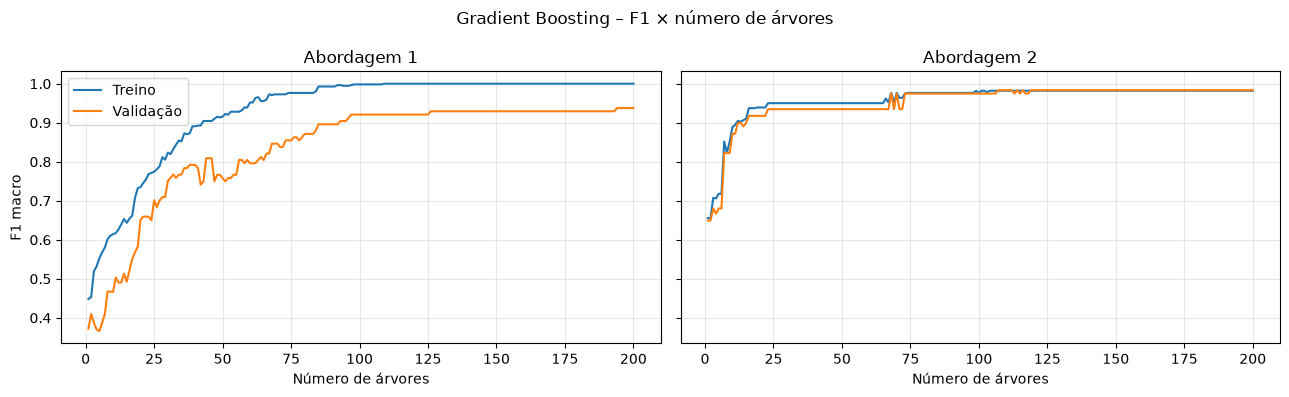

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, ab in zip(axes, ABORDAGENS):
    Xtr, ytr, Xval, yval, _, _ = dados[ab]
    m = modelos[ab]
    f1_tr = [f1_score(ytr, p, average="macro") for p in m.staged_predict(Xtr)]
    f1_va = [f1_score(yval, p, average="macro") for p in m.staged_predict(Xval)]
    eixo = range(1, len(f1_tr) + 1)
    ax.plot(eixo, f1_tr, label="Treino")
    ax.plot(eixo, f1_va, label="Validação")
    ax.set_title(f"Abordagem {ab}")
    ax.set_xlabel("Número de árvores")
    ax.grid(alpha=.3)

axes[0].set_ylabel("F1 macro")
axes[0].legend()
fig.suptitle("Gradient Boosting – F1 × número de árvores")
fig.tight_layout()
fig.savefig("boosting_overfitting.png", dpi=150)
plt.show()

### 3.3 Interpretação dos resultados de overfitting

- **Abordagem 1:** a validação sobe de forma contínua (de cerca de 0,37 para cerca de 0,94) conforme as árvores são adicionadas, o que mostra o boosting funcionando: cada árvore corrige parte dos erros das anteriores. Há **algum overfitting**: o treino chega a 1,0 e a validação fica em cerca de 0,94. Mesmo assim, a validação não cai no final, então 200 árvores não prejudicam.
- **Abordagem 2:** **não há overfitting relevante**. Treino e validação ficam praticamente iguais (cerca de 0,98), mesmo usando árvores de uma única pergunta (`max_depth = 1`). As features já resumem bem o problema.

## 4. Resultados dos experimentos

### 4.1 Comparação entre as abordagens

Desempenho dos modelos escolhidos na **validação**, com o custo de treino.

In [16]:
linhas = []
for ab in ABORDAGENS:
    Xtr, ytr, Xval, yval, _, _ = dados[ab]
    linhas.append({"abordagem": ab, "n_features": Xtr.shape[1],
                   **metricas(yval, modelos[ab].predict(Xval)),
                   "n_arvores": melhores_params[ab]["n_estimators"],
                   "profundidade_arvores": melhores_params[ab]["max_depth"],
                   "tempo_treino_ms": tempos[ab]})
comparacao_val = pd.DataFrame(linhas).set_index("abordagem")
comparacao_val.round(3)

,n_features,acuracia,precision,recall,f1,n_arvores,profundidade_arvores,tempo_treino_ms
abordagem,,,,,,,,
1,9,0.978,0.984,0.908,0.938,200,3,1114.101
2,15,0.978,0.984,0.983,0.983,200,1,1258.250


### 4.2 Gráfico comparativo

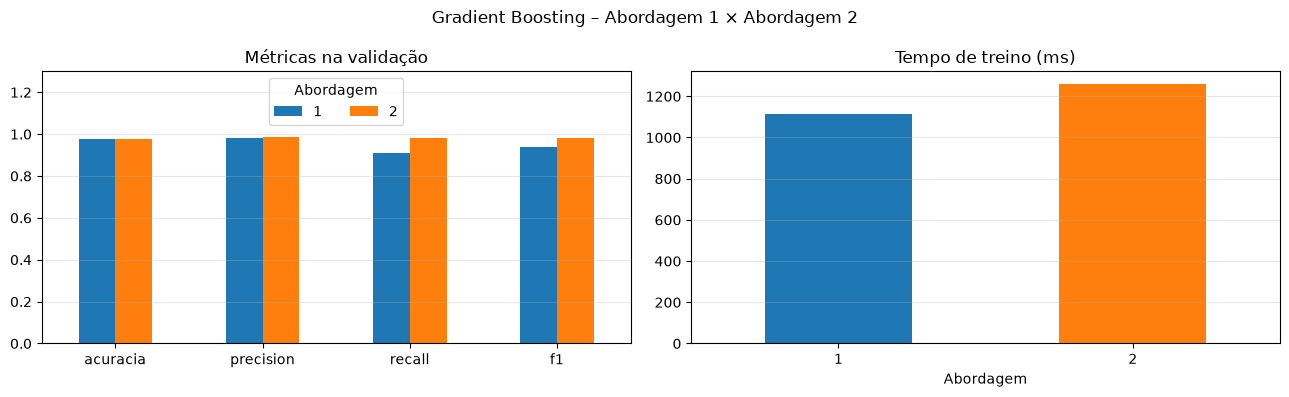

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

comparacao_val[["acuracia", "precision", "recall", "f1"]].T.plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Métricas na validação")
axes[0].set_ylim(0, 1.3)
axes[0].legend(title="Abordagem", loc="upper center", ncol=2)
axes[0].grid(axis="y", alpha=.3)

comparacao_val["tempo_treino_ms"].plot.bar(ax=axes[1], rot=0, color=["tab:blue", "tab:orange"])
axes[1].set_title("Tempo de treino (ms)")
axes[1].set_xlabel("Abordagem")
axes[1].grid(axis="y", alpha=.3)

fig.suptitle("Gradient Boosting – Abordagem 1 × Abordagem 2")
fig.tight_layout()
fig.savefig("boosting_comparativo.png", dpi=150)
plt.show()

### 4.3 Avaliação no conjunto de teste

Avaliação **única** dos modelos escolhidos, em tabuleiros que não foram usados nem para treinar nem para escolher parâmetros. Os modelos são salvos (`.joblib`) para uso no front end.

===== Abordagem 1 =====
              precision    recall  f1-score   support

      Empate       0.33      0.33      0.33         3
    O venceu       0.97      1.00      0.98        30
    Tem jogo       0.93      0.93      0.93        30
    X venceu       1.00      0.97      0.98        30

    accuracy                           0.95        93
   macro avg       0.81      0.81      0.81        93
weighted avg       0.95      0.95      0.95        93

===== Abordagem 2 =====
              precision    recall  f1-score   support

      Empate       1.00      1.00      1.00         3
    O venceu       1.00      1.00      1.00        30
    Tem jogo       1.00      0.87      0.93        30
    X venceu       0.88      1.00      0.94        30

    accuracy                           0.96        93
   macro avg       0.97      0.97      0.97        93
weighted avg       0.96      0.96      0.96        93



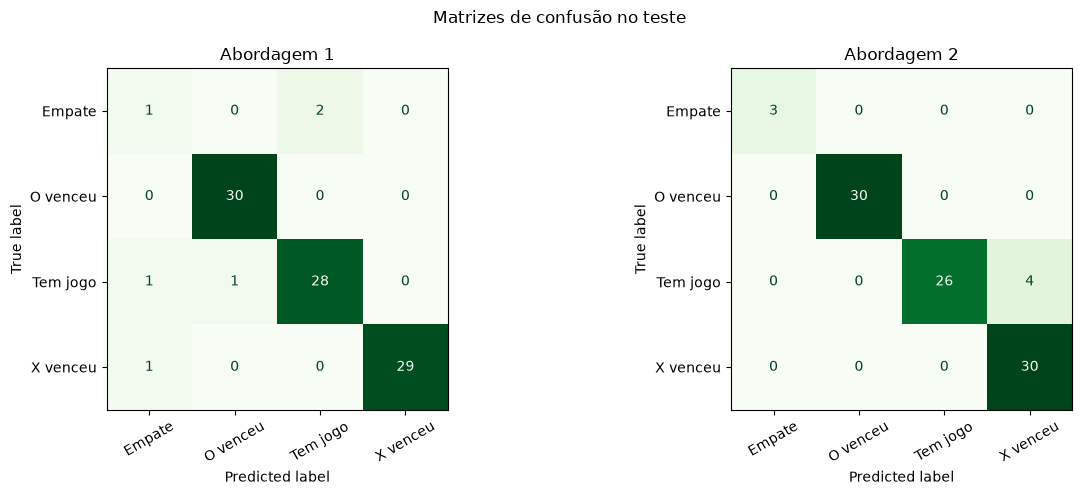

,abordagem,acuracia,precision,recall,f1,tempo_treino_ms
0,1,0.946,0.809,0.808,0.808,1114.101
1,2,0.957,0.971,0.967,0.967,1258.250


In [18]:
resultados_teste = []
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, ab in zip(axes, ABORDAGENS):
    _, _, _, _, Xte, yte = dados[ab]
    m = modelos[ab]
    t0 = time.perf_counter()
    pred = m.predict(Xte)
    tempo_pred = (time.perf_counter() - t0) * 1000

    print(f"===== Abordagem {ab} =====")
    print(classification_report(yte, pred, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(yte, pred, cmap="Greens", ax=ax, colorbar=False)
    ax.set_title(f"Abordagem {ab}")
    ax.tick_params(axis="x", rotation=30)

    resultados_teste.append({"abordagem": ab, **melhores_params[ab], **metricas(yte, pred),
                             "tempo_treino_ms": tempos[ab], "tempo_pred_ms": tempo_pred})
    joblib.dump(m, f"boosting_modelo_ab{ab}.joblib")

fig.suptitle("Matrizes de confusão no teste")
fig.tight_layout()
fig.savefig("boosting_matriz_confusao.png", dpi=150)
plt.show()

resultados_teste = pd.DataFrame(resultados_teste)
resultados_teste.to_csv("boosting_resultados_teste.csv", index=False)
resultados_teste[["abordagem", "acuracia", "precision", "recall", "f1",
                  "tempo_treino_ms"]].round(3)

### 4.4 Análise dos resultados

**Em que o modelo se apoia:** importância das features em cada abordagem.

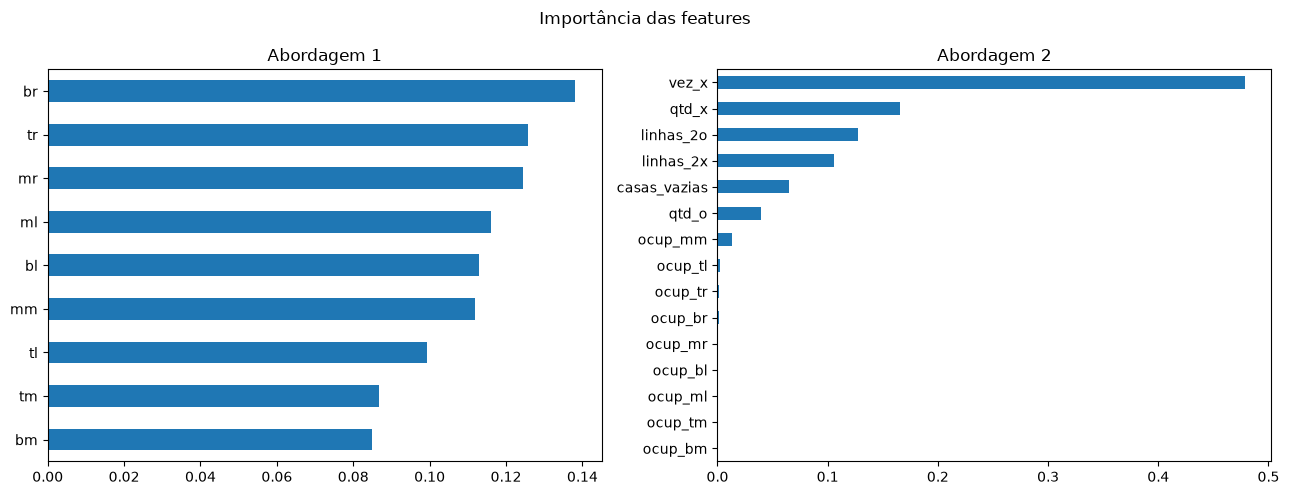

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ab in zip(axes, ABORDAGENS):
    imp = pd.Series(modelos[ab].feature_importances_, dados[ab][0].columns).sort_values()
    imp.plot.barh(ax=ax)
    ax.set_title(f"Abordagem {ab}")
fig.suptitle("Importância das features")
fig.tight_layout()
fig.savefig("boosting_importancia.png", dpi=150)
plt.show()

- **As duas abordagens têm acurácia alta** (cerca de 0,95 e 0,96), mas o **F1 macro** mostra a diferença: cerca de 0,81 na abordagem 1 contra cerca de 0,97 na abordagem 2. A diferença está no *Empate*: a abordagem 1 acerta 1 dos 3 empates do teste; a abordagem 2 acerta todos.
- **O boosting resolve a abordagem 1 muito melhor que uma árvore sozinha:** combinando 200 árvores que corrigem umas às outras, ele consegue reconhecer padrões de três em linha a partir das casas isoladas, o que uma única árvore não consegue.
- **Na abordagem 2, o modelo é mais simples:** árvores de uma única pergunta bastam, e o treino é mais rápido.
- **Cautela com o Empate:** o teste tem só 3 empates, então cada acerto ou erro muda bastante o F1 dessa classe.

## 5. Conclusão

- A **abordagem 2** é a mais adequada **e a menos custosa** para o Gradient Boosting: melhor F1 macro, sem overfitting, árvores mais simples e treino mais rápido.
- O boosting é o algoritmo mais robusto à escolha do pré-processamento: mesmo na abordagem 1 ele alcança acurácia alta, porque a combinação de muitas árvores compensa a falta de features informativas.
- A principal desvantagem é o **custo**: o treino é bem mais lento que o de uma árvore única, e o modelo é menos interpretável, porque a decisão é a soma de dezenas ou centenas de árvores.